In [1]:
import jax 
import jax.numpy as np
import jax.tree_util as jtu
import functools as ft
import zodiax as zdx
import dLux as dl
import matplotlib.pyplot as plt

dLux: Jax is running in 32-bit, to enable 64-bit visit: https://jax.readthedocs.io/en/latest/notebooks/Common_Gotchas_in_JAX.html#double-64bit-precision


In [2]:
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 120

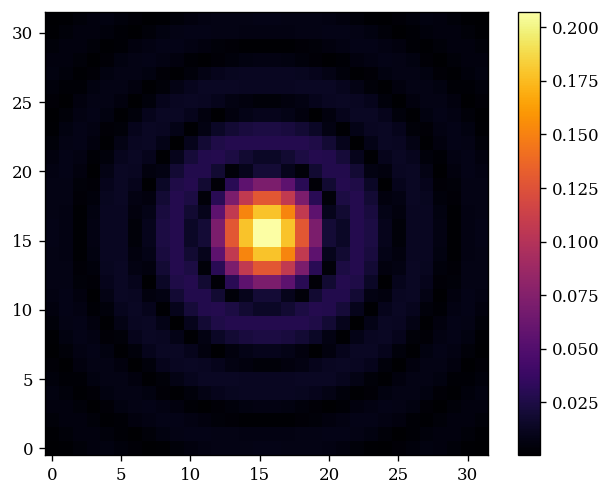

In [3]:
optics = dl.utils.simple_optical_system(1., 256, 32, 5e-2)
psf = optics.propagate_mono(1e-6)

plt.imshow(psf**0.5)
plt.colorbar()
plt.show()

In [4]:
pytree = optics.set("CreateWavefront.diameter", np.array(0.9))
args = ['CreateWavefront.diameter', 'AngularMFT.pixel_scale_out']

@zdx.filter_jit
@zdx.filter_grad(args)
def loss_fn(model, data):
    return np.square(model.propagate_mono(1e-6) - data).sum()

grads = loss_fn(pytree, psf)
grads.get(args)

[Array(-0.00971625, dtype=float32, weak_type=True),
 Array(-36074.15, dtype=float32)]

In [45]:
%%timeit
grads = loss_fn(pytree, psf)


1.57 ms ± 34.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [8]:

def loss_fn(model, data):
    return np.square(model.propagate_mono(1e-6) - data).sum()

grad_loss = zdx.filter_grad(args)(loss_fn)

In [9]:
grad_loss(pytree, psf)

Optics(
  layers={
    'CreateWavefront':
    CreateWavefront(
      name='CreateWavefront',
      npixels=None,
      diameter=f32[],
      wavefront_type='Angular'
    ),
    'CircularAperture':
    StaticAperture(name='CircularAperture', aperture=None),
    'NormaliseWavefront':
    NormaliseWavefront(name='NormaliseWavefront'),
    'AngularMFT':
    AngularMFT(
      name='AngularMFT',
      inverse=None,
      npixels_out=None,
      pixel_scale_out=f32[],
      shift=None,
      pixel_shift=None
    )
  }
)

In [30]:
import zodiax as zdx

class Linear(zdx.ExtendedBase):
    m : float
    b : float

    def __init__(self, m, b):
        self.m = np.asarray(m, float)
        self.b = np.asarray(b, float)
    
    def model(self, x):
        return self.m * x + self.b

# Make model
linear = Linear(1, 2)

# Differentiate with respect to the m parameter
args = 'm'
pytree_args = linear.get_args(args)

# Use the arguments to filter the gradient
@zdx.filter_grad(args)
def loss_fn(model, x):
    return np.abs(model.model(x) - x)

# Use the pytree to filter the gradient
@zdx.filter_grad(pytree_args)
def loss_fn(model, x):
    return np.square(model.model(x) - x)

In [21]:
pytree_args

Linear(m=True, b=False)

In [18]:
linear.model(1)

3.0

In [17]:
linear.model(np.linspace(0, 10, 100))

Array([ 2.       ,  2.10101  ,  2.2020202,  2.3030303,  2.4040403,
        2.5050504,  2.6060605,  2.7070708,  2.8080807,  2.909091 ,
        3.0101008,  3.1111112,  3.2121212,  3.3131313,  3.4141414,
        3.5151515,  3.6161616,  3.7171717,  3.8181818,  3.9191918,
        4.0202017,  4.121212 ,  4.2222223,  4.323232 ,  4.4242425,
        4.5252523,  4.6262627,  4.727273 ,  4.828283 ,  4.9292927,
        5.030303 ,  5.1313133,  5.232323 ,  5.333333 ,  5.4343433,
        5.5353537,  5.6363635,  5.7373734,  5.8383837,  5.939394 ,
        6.040404 ,  6.141414 ,  6.242424 ,  6.3434343,  6.444444 ,
        6.5454545,  6.6464643,  6.7474747,  6.848485 ,  6.949495 ,
        7.050505 ,  7.151515 ,  7.2525253,  7.353535 ,  7.4545455,
        7.5555553,  7.6565657,  7.7575755,  7.858586 ,  7.9595957,
        8.060606 ,  8.161615 ,  8.262627 ,  8.363636 ,  8.464646 ,
        8.565657 ,  8.666666 ,  8.767677 ,  8.868687 ,  8.969697 ,
        9.070707 ,  9.171717 ,  9.272727 ,  9.373737 ,  9.4747

In [20]:
dir(kp)

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'count',
 'index']

In [17]:
kps = _generate_key_paths_(optics)
kps[0]

TypeError: _generate_key_paths_() missing 1 required positional argument: 'tree'

In [7]:
optics = dl.utils.SimpleOpticalSystem(512, 1, 32, 1e-3)

AttributeError: module 'dLux.utils' has no attribute 'SimpleOpticalSystem'

---

## Chat GPT

In [27]:
def my_decorator(*dec_args, **dec_kwargs):
    def wrapper(func):
        def inner_wrapper(*args, **kwargs):
            # Add some code to be executed before the decorated function is called
            print(f"Decorator args: {dec_args}")
            print(f"Decorator kwargs: {dec_kwargs}")
            print("Before the function is called.")

            # Call the decorated function with the original arguments
            result = func(*args, **kwargs)

            # Add some code to be executed after the decorated function is called
            print("After the function is called.")

            # Return the result of the decorated function
            return result

        # Return the inner wrapper function, which will be used to decorate the original function
        return inner_wrapper
    
    # Return the wrapper function, which takes the function to be decorated as an argument
    return wrapper

In [28]:
@my_decorator("arg1", "arg2", keyword1="value1", keyword2="value2")
def my_function(x, y):
    return x + y

my_function(1, 2)

Decorator args: ('arg1', 'arg2')
Decorator kwargs: {'keyword1': 'value1', 'keyword2': 'value2'}
Before the function is called.
After the function is called.


3

In [87]:
# from equinox import filter_value_and_grad
import equinox as eqx

def filter_grad(filter_spec, *filter_args, **filter_kwargs):
    def wrapper(func):
        @ft.wraps(func)
        def inner_wrapper(pytree, *args, **kwargs):
            @eqx.filter_grad(*filter_args, **filter_kwargs)
            def recombine(diff, non_diff):
                return func(eqx.combine(diff, non_diff), *args, **kwargs)
            return recombine(*eqx.partition(pytree, filter_spec))
        return inner_wrapper
    return wrapper

def filter_value_and_grad(filter_spec, *filter_args, **filter_kwargs):
    def wrapper(func):
        @ft.wraps(func)
        def inner_wrapper(pytree, *args, **kwargs):
            @eqx.filter_value_and_grad(*filter_args, **filter_kwargs)
            def recombine(diff, non_diff):
                return func(eqx.combine(diff, non_diff), *args, **kwargs)
            return recombine(*eqx.partition(pytree, filter_spec))
        return inner_wrapper
    return wrapper

In [88]:
pytree = optics.set("CreateWavefront.diameter", np.array(0.9))
args = pytree.get_args("CreateWavefront.diameter")

@filter_value_and_grad(args)
def loss_fn(pytree, data):
    """Test docstring"""
    return np.square(pytree.propagate_mono(1e-6) - data).sum()

In [89]:
loss, grads = loss_fn(pytree, psf)
print(loss)
print(grads.CreateWavefront.diameter)

0.00049114093
-0.009716247


In [90]:
loss_fn?

Signature: loss_fn(pytree, data)
Docstring: Test docstring
File:      /var/folders/28/6s47s91d14ldjdrljs4d1hxw0000gn/T/ipykernel_68609/3885649931.py
Type:      function